In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("sales_data.csv")

print("Dataset loaded successfully")
df.head()


Dataset loaded successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [5]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())
df.describe()

Dataset Shape:
(100, 7)

Column Names:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Rows:
0


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [6]:
required_columns = [
    "Date",
    "Product",
    "Quantity",
    "Price",
    "Customer_ID",
    "Region",
    "Total_Sales"
]

missing_columns = []

for_column_error = False

In [7]:
clean_df = df.copy()

# Remove duplicate rows
clean_df = clean_df.drop_duplicates()

# Convert Date column
clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="coerce")

# Convert numeric columns
numeric_columns = ["Quantity", "Price", "Total_Sales"]

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")
    clean_df[column] = clean_df[column].fillna(clean_df[column].median())

# Fill missing categorical values
clean_df["Product"] = clean_df["Product"].fillna("Unknown")
clean_df["Customer_ID"] = clean_df["Customer_ID"].fillna("Unknown")
clean_df["Region"] = clean_df["Region"].fillna("Unknown")

# Remove invalid date rows
clean_df = clean_df.dropna(subset=["Date"])

# Avoid negative values
clean_df["Quantity"] = clean_df["Quantity"].clip(lower=0)
clean_df["Price"] = clean_df["Price"].clip(lower=0)

# Recalculate Total Sales
clean_df["Total_Sales"] = clean_df["Quantity"] * clean_df["Price"]

print("Data cleaning completed successfully")
clean_df.head()

Data cleaning completed successfully


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [8]:
total_revenue = clean_df["Total_Sales"].sum()
total_quantity = clean_df["Quantity"].sum()
average_sales = clean_df["Total_Sales"].mean()
average_price = clean_df["Price"].mean()
total_customers = clean_df["Customer_ID"].nunique()

print("Total Revenue: ₹", total_revenue)
print("Total Quantity Sold:", total_quantity)
print("Average Sales: ₹", round(average_sales, 2))
print("Average Price: ₹", round(average_price, 2))
print("Total Unique Customers:", total_customers)

Total Revenue: ₹ 12365048
Total Quantity Sold: 478
Average Sales: ₹ 123650.48
Average Price: ₹ 25808.51
Total Unique Customers: 100


In [10]:
product_sales = clean_df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

print("Product-wise Sales:")
product_sales

Product-wise Sales:


,Total_Sales
Product,
Laptop,3889210
Tablet,2884340
Phone,2859394
Headphones,1384033
Monitor,1348071


In [11]:
region_sales = clean_df.groupby("Region")["Total_Sales"].sum().sort_values(ascending=False)

print("Region-wise Sales:")
region_sales

Region-wise Sales:


,Total_Sales
Region,
North,3983635
South,3737852
East,2519639
West,2123922


In [12]:
product_quantity = clean_df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

print("Product-wise Quantity Sold:")
product_quantity

Product-wise Quantity Sold:


,Quantity
Product,
Laptop,136
Tablet,127
Phone,101
Monitor,66
Headphones,48


In [13]:
monthly_sales = clean_df.groupby(clean_df["Date"].dt.to_period("M"))["Total_Sales"].sum()

print("Monthly Sales:")
monthly_sales

Monthly Sales:


,Total_Sales
Date,
2024-01,4120524
2024-02,2656050
2024-03,4485006
2024-04,1103468


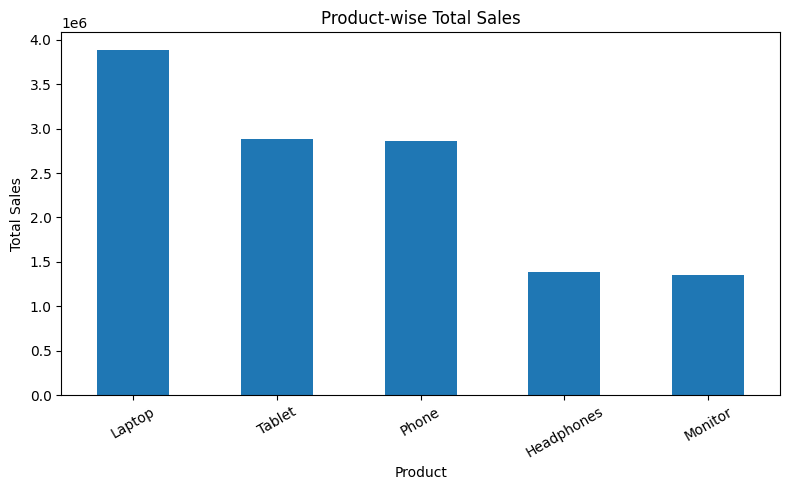

In [14]:
plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar")

plt.title("Product-wise Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

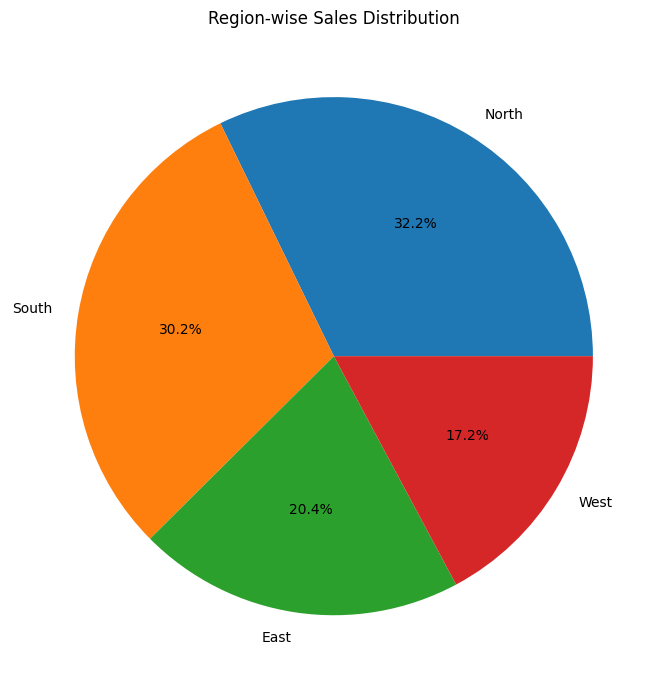

In [15]:
plt.figure(figsize=(7, 7))
region_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Region-wise Sales Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

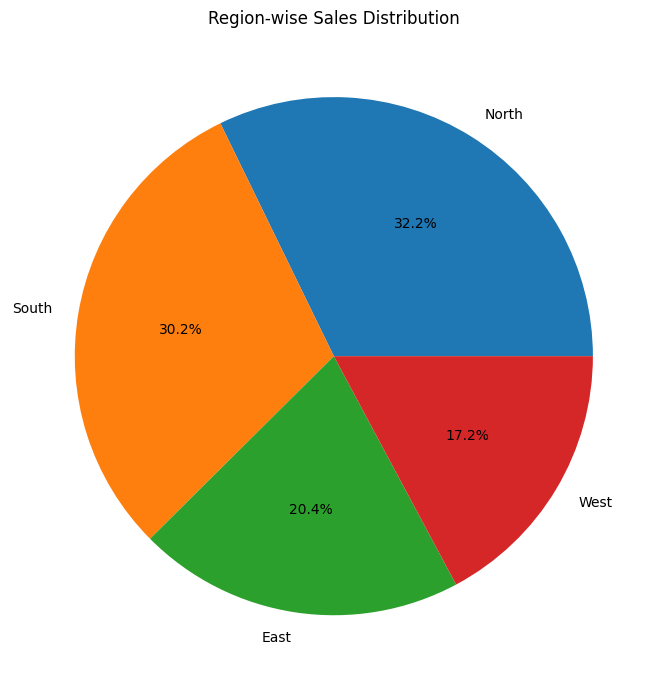

In [16]:
plt.figure(figsize=(7, 7))
region_sales.plot(kind="pie", autopct="%1.1f%%")

plt.title("Region-wise Sales Distribution")
plt.ylabel("")
plt.tight_layout()
plt.show()

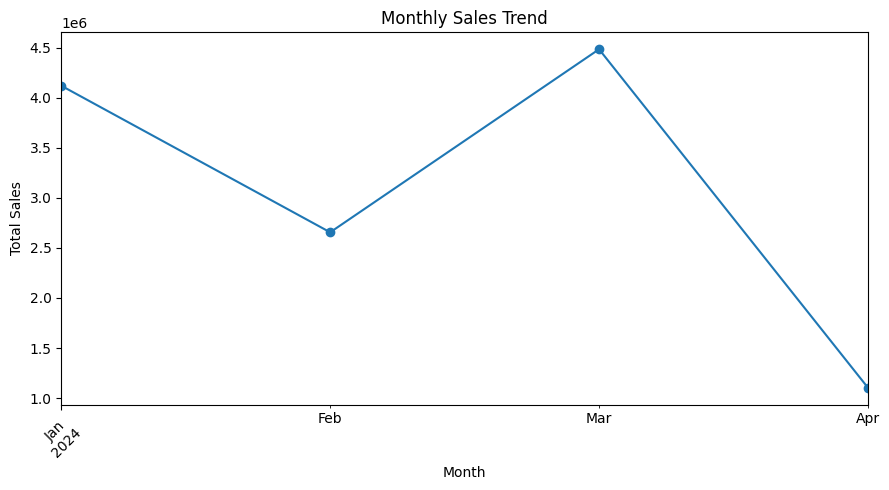

In [17]:
plt.figure(figsize=(9, 5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
top_product = product_sales.idxmax()
top_region = region_sales.idxmax()
most_sold_product = product_quantity.idxmax()

print("Meaningful Insights")
print("-------------------")
print(f"1. The highest revenue-generating product is {top_product}.")
print(f"2. The best performing region is {top_region}.")
print(f"3. The most sold product by quantity is {most_sold_product}.")
print("4. Product-wise sales chart helps identify the most profitable products.")
print("5. Region-wise sales chart helps understand which region contributes more revenue.")
print("6. Monthly sales trend helps observe business performance over time.")
print("7. Quantity and total sales show a positive relationship because higher quantity usually increases revenue.")

Meaningful Insights
-------------------
1. The highest revenue-generating product is Laptop.
2. The best performing region is North.
3. The most sold product by quantity is Laptop.
4. Product-wise sales chart helps identify the most profitable products.
5. Region-wise sales chart helps understand which region contributes more revenue.
6. Monthly sales trend helps observe business performance over time.
7. Quantity and total sales show a positive relationship because higher quantity usually increases revenue.


In [19]:
print("Conclusion")
print("----------")
print("This project successfully completed a full data analysis pipeline.")
print("The dataset was loaded, validated, cleaned, analyzed, and visualized using matplotlib.")
print("The analysis helps understand product performance, regional sales contribution, monthly sales trend, and customer purchase behavior.")

Conclusion
----------
This project successfully completed a full data analysis pipeline.
The dataset was loaded, validated, cleaned, analyzed, and visualized using matplotlib.
The analysis helps understand product performance, regional sales contribution, monthly sales trend, and customer purchase behavior.
